# Evaluierung des SFT-Übersetzungsmodells auf dem Lebenshilfe-Datensatz
### Masterarbeit: Automatische Übersetzung von Alltagssprache (AS) in Leichte Sprache (LS)

Dieses Notebook evaluiert das **Supervised Fine-Tuned (SFT)** Basismodell auf dem unabhängigen **Lebenshilfe-Testdatensatz**:
1. **Modell- & Tokenizer-Initialisierung:** Laden aus dem SFT-Modellordner (`results/models/new_pipeline/sft`).
2. **Reward- & Metrik-Setup:**
   - **Stil & Einfachheit ($R_{\text{style}}$):** BiLSTM Synthetic Regressor.
   - **Semantische Ähnlichkeit ($R_{\text{sem}}$):** Sentence-BERT Ähnlichkeit zur AS-Quelle.
   - **Referenz-Treue:** SBERT Ähnlichkeit zur menschlichen LS-Referenz.
   - **Composite Reward:** Kombinierter Qualitäts-Score.
3. **Batch-Übersetzung** aller Artikel des Lebenshilfe-Datensatzes (ohne Prompt-Prefix).
4. **Quantitative & Statistische Auswertung** (Mittelwert, Standardabweichung, Verteilungen).
5. **Qualitatives Stichproben-Audit** & Interaktive Übersetzung.

In [1]:
import os
import sys
import json
import random
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import spacy
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from sentence_transformers import SentenceTransformer, util

# Arbeitsverzeichnis auf Projekt-Root setzen
while not os.path.exists(".git"):
    parent = os.path.dirname(os.getcwd())
    if parent == os.getcwd():
        break
    os.chdir("..")

print("Arbeitsverzeichnis:", os.getcwd())
DEVICE = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print(f"Nutze Device: {DEVICE}")

Arbeitsverzeichnis: /home/fiete/master-thesis
Nutze Device: cuda


In [2]:
# ==============================================================================
# ZENTRALE KONFIGURATION & PFADE
# ==============================================================================
SFT_PATHS = [
    "results/models/sft",
    "results/models/new_pipeline/sft"
]
SFT_MODEL_PATH = next((p for p in SFT_PATHS if os.path.exists(p)), SFT_PATHS[0])

# Lebenshilfe Datensatz-Pfad (mit Fallback)
LH_PATHS = [
    "data/new_pipeline/lebenshilfe/lebenshilfe_dataset_clean.json",
    "data/new_pipeline/lebenshilfe/lebenshilfe_dataset.json",
    "data/lebenshilfe/lebenshilfe_dataset.json"
]
LH_DATASET_PATH = next((p for p in LH_PATHS if os.path.exists(p)), LH_PATHS[0])

# Reward Model & Vocab Pfade (mit Fallback)
REWARD_MODEL_PATHS = [
    "results/models/bilstm_synthetic_regression.pt",
    "results/models/best_bilstm_regressor.pt"
]
REWARD_MODEL_PATH = next((p for p in REWARD_MODEL_PATHS if os.path.exists(p)), REWARD_MODEL_PATHS[0])

VOCAB_PATHS = [
    "data/vocabs/synthetic_vocab.json",
    "data/new_pipeline/vocabs/synthetic_vocab.json",
    "data/vocabs/mixup_vocab.json"
]
REWARD_VOCAB_PATH = next((p for p in VOCAB_PATHS if os.path.exists(p)), VOCAB_PATHS[0])

SBERT_MODEL_NAME = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"

W_STYLE = 0.5
W_SEM = 0.5
MAX_SOURCE_LEN = 256
MAX_TARGET_LEN = 256

print(f"SFT Modell-Ordner:     {SFT_MODEL_PATH}")
print(f"Lebenshilfe-Datensatz: {LH_DATASET_PATH}")
print(f"Reward Modell:         {REWARD_MODEL_PATH}")
print(f"Reward Vokabular:      {REWARD_VOCAB_PATH}")

SFT Modell-Ordner:     results/models/new_pipeline/sft
Lebenshilfe-Datensatz: data/new_pipeline/lebenshilfe/lebenshilfe_dataset_clean.json
Reward Modell:         results/models/bilstm_synthetic_regression.pt
Reward Vokabular:      data/vocabs/synthetic_vocab.json


## 1. SFT-Modell & Tokenizer aus Ordner laden

In [3]:
print(f"Lade Tokenizer und SFT-Modell aus: {SFT_MODEL_PATH}...")
try:
    tokenizer = AutoTokenizer.from_pretrained(SFT_MODEL_PATH, use_fast=False)
except Exception:
    tokenizer = AutoTokenizer.from_pretrained("facebook/mbart-large-50", use_fast=False)

tokenizer.src_lang = "de_DE"
tokenizer.tgt_lang = "de_DE"

# Universal-Lader: Unterstützt HuggingFace-Ordner, LoRA-Adapter und PyTorch .pt State-Dicts
pt_file = None
if os.path.isfile(SFT_MODEL_PATH) and SFT_MODEL_PATH.endswith((".pt", ".pth", ".bin")):
    pt_file = SFT_MODEL_PATH
elif os.path.isdir(SFT_MODEL_PATH):
    for cand in ["sft.pt", "pytorch_model.bin", "model.pt"]:
        if os.path.exists(os.path.join(SFT_MODEL_PATH, cand)):
            pt_file = os.path.join(SFT_MODEL_PATH, cand)
            break

has_config = os.path.isdir(SFT_MODEL_PATH) and os.path.exists(os.path.join(SFT_MODEL_PATH, "config.json"))
has_adapter = os.path.isdir(SFT_MODEL_PATH) and os.path.exists(os.path.join(SFT_MODEL_PATH, "adapter_config.json"))

if has_adapter and not has_config:
    print("LoRA Adapter-Verzeichnis erkannt. Lade Basismodell und verbinde Adapter...")
    from peft import PeftModel
    base_model = AutoModelForSeq2SeqLM.from_pretrained("facebook/mbart-large-50").to(DEVICE)
    peft_sft = PeftModel.from_pretrained(base_model, SFT_MODEL_PATH)
    sft_model = peft_sft.merge_and_unload()
elif has_config:
    print(f"Lade vollständiges HuggingFace-Modell aus {SFT_MODEL_PATH}...")
    sft_model = AutoModelForSeq2SeqLM.from_pretrained(SFT_MODEL_PATH).to(DEVICE)
elif pt_file and os.path.exists(pt_file):
    print(f"Lade State-Dict aus {pt_file} in facebook/mbart-large-50...")
    sft_model = AutoModelForSeq2SeqLM.from_pretrained("facebook/mbart-large-50").to(DEVICE)
    sd = torch.load(pt_file, map_location=DEVICE)
    if isinstance(sd, dict):
        sd = sd.get("model_state_dict", sd.get("state_dict", sd))
    sft_model.load_state_dict(sd)
else:
    sft_model = AutoModelForSeq2SeqLM.from_pretrained(SFT_MODEL_PATH).to(DEVICE)

sft_model.eval()
print("SFT-Modell und Tokenizer erfolgreich geladen!")


Lade Tokenizer und SFT-Modell aus: results/models/new_pipeline/sft...
Lade vollständiges HuggingFace-Modell aus results/models/new_pipeline/sft...
SFT-Modell und Tokenizer erfolgreich geladen!


## 2. Reward-Evaluator & SBERT Setup

In [4]:
class BiLSTMRegressor(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, dropout=0.3):
        super(BiLSTMRegressor, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, 1)
        self.dropout = nn.Dropout(dropout)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(embedded)
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        out = self.fc(self.dropout(hidden))
        return self.sigmoid(out)

# Vokabular laden
with open(REWARD_VOCAB_PATH, "r", encoding="utf-8") as f:
    vocab_data = json.load(f)
    reward_stoi = vocab_data.get("stoi", vocab_data)

bilstm_model = BiLSTMRegressor(len(reward_stoi), embed_dim=128, hidden_dim=128)
if os.path.exists(REWARD_MODEL_PATH):
    raw_state = torch.load(REWARD_MODEL_PATH, map_location="cpu")
    if isinstance(raw_state, dict):
        raw_state = raw_state.get("model_state_dict", raw_state.get("state_dict", raw_state))
    bilstm_model.load_state_dict(raw_state)
    bilstm_model.eval()
    print(f"BiLSTM Regressor erfolgreich geladen von: {REWARD_MODEL_PATH}")
else:
    print(f"Warnung: Reward Modell {REWARD_MODEL_PATH} nicht gefunden.")

try:
    nlp = spacy.load("de_core_news_sm", disable=["ner", "tagger", "lemmatizer"])
except Exception:
    nlp = spacy.blank("de")
    nlp.add_pipe("sentencizer")

def predict_simplicity_score(texts):
    scores = []
    unk_idx = reward_stoi.get("<unk>") or reward_stoi.get("<UNK>") or 1
    for text in texts:
        doc = nlp(str(text or ""))
        tokens = [t.text.lower() for t in doc if not t.is_space]
        indices = [reward_stoi.get(t, unk_idx) for t in tokens[:150]]
        if len(indices) == 0:
            indices = [0]
        inp_tensor = torch.tensor([indices], dtype=torch.long, device="cpu")
        with torch.no_grad():
            score = bilstm_model(inp_tensor).item()
        scores.append(score)
    return np.array(scores)

print(f"Lade SBERT Modell: {SBERT_MODEL_NAME}...")
sbert_model = SentenceTransformer(SBERT_MODEL_NAME, device="cpu")

def predict_semantic_similarity(source_texts, generated_texts):
    emb_src = sbert_model.encode(source_texts, convert_to_tensor=True, show_progress_bar=False)
    emb_gen = sbert_model.encode(generated_texts, convert_to_tensor=True, show_progress_bar=False)
    cosine_sims = util.cos_sim(emb_src, emb_gen).diagonal().cpu().numpy()
    return cosine_sims

class CompositeRewardEvaluator:
    def __init__(self, w_style=0.5, w_sem=0.5):
        self.w_style = w_style
        self.w_sem = w_sem
        
    def compute_reward(self, source_texts, generated_texts):
        r_style = predict_simplicity_score(generated_texts)
        r_sem = predict_semantic_similarity(source_texts, generated_texts)
        r_sem_norm = np.clip((r_sem + 1.0) / 2.0, 0.0, 1.0)
        total_reward = self.w_style * r_style + self.w_sem * r_sem_norm
        return total_reward, r_style, r_sem_norm

reward_evaluator = CompositeRewardEvaluator(w_style=W_STYLE, w_sem=W_SEM)
print("Reward Evaluator erfolgreich initialisiert!")

BiLSTM Regressor erfolgreich geladen von: results/models/bilstm_synthetic_regression.pt
Lade SBERT Modell: sentence-transformers/paraphrase-multilingual-mpnet-base-v2...
Reward Evaluator erfolgreich initialisiert!


## 3. Lebenshilfe-Datensatz laden & SFT-Übersetzungen generieren

In [5]:
with open(LH_DATASET_PATH, "r", encoding="utf-8") as f:
    lh_data = json.load(f)

print(f"Lebenshilfe Datensatz geladen: {len(lh_data)} Artikel-Paare.")

def evaluate_sft_on_lebenshilfe(model, tokenizer, lh_data, evaluator, batch_size=8):
    model.eval()
    as_texts = [str(item.get("as_text") or "").strip() for item in lh_data]
    ls_ref_texts = [str(item.get("ls_text") or "").strip() for item in lh_data]
    
    forced_bos_id = tokenizer.lang_code_to_id.get("de_DE", None) if hasattr(tokenizer, "lang_code_to_id") else None
    
    gen_texts = []
    for i in tqdm(range(0, len(as_texts), batch_size), desc="Generiere SFT-Übersetzungen"):
        batch_src = as_texts[i : i + batch_size]
        inputs = tokenizer(batch_src, padding=True, truncation=True, max_length=MAX_SOURCE_LEN, return_tensors="pt").to(DEVICE)
        
        with torch.no_grad():
            outputs = model.generate(
                input_ids=inputs["input_ids"],
                attention_mask=inputs.get("attention_mask"),
                max_length=MAX_TARGET_LEN,
                num_beams=4,
                repetition_penalty=2.5,
                no_repeat_ngram_size=3,
                early_stopping=True,
                forced_bos_token_id=forced_bos_id
            )
        decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)
        gen_texts.extend([d.strip() for d in decoded])
        
    print("Berechne Reward- und Ähnlichkeitsmetriken...")
    tot_reward, r_style, r_sem_norm = evaluator.compute_reward(as_texts, gen_texts)
    sim_to_ref = predict_semantic_similarity(ls_ref_texts, gen_texts)
    sim_to_ref_norm = np.clip((sim_to_ref + 1.0) / 2.0, 0.0, 1.0)
    
    df_res = pd.DataFrame({
        "as_text": as_texts,
        "ls_reference": ls_ref_texts,
        "sft_translation": gen_texts,
        "simplicity_score": r_style,
        "sbert_sim_to_as": r_sem_norm,
        "sbert_sim_to_ref": sim_to_ref_norm,
        "composite_reward": tot_reward,
        "as_char_len": [len(t) for t in as_texts],
        "gen_char_len": [len(t) for t in gen_texts]
    })
    return df_res

sft_eval_df = evaluate_sft_on_lebenshilfe(sft_model, tokenizer, lh_data, reward_evaluator)

Lebenshilfe Datensatz geladen: 44 Artikel-Paare.


Generiere SFT-Übersetzungen:   0%|          | 0/6 [00:00<?, ?it/s]

Berechne Reward- und Ähnlichkeitsmetriken...


## 4. Statistische Gesamtauswertung (SFT)

In [6]:
print("\n=================== SFT EVALUIERUNGSERGEBNISSE (LEBENSHILFE) ===================")
print(f"Ø Simplicity-Score (R_style):       {sft_eval_df['simplicity_score'].mean():.4f} ± {sft_eval_df['simplicity_score'].std():.4f}")
print(f"Ø SBERT-Ähnlichkeit zur AS-Quelle:  {sft_eval_df['sbert_sim_to_as'].mean():.4f} ± {sft_eval_df['sbert_sim_to_as'].std():.4f}")
print(f"Ø SBERT-Ähnlichkeit zu LS-Referenz: {sft_eval_df['sbert_sim_to_ref'].mean():.4f} ± {sft_eval_df['sbert_sim_to_ref'].std():.4f}")
print(f"Ø Composite Reward:                 {sft_eval_df['composite_reward'].mean():.4f} ± {sft_eval_df['composite_reward'].std():.4f}")
print("=================================================================================\n")

# Statistische Kennzahlen anzeigen
metrics_cols = ["simplicity_score", "sbert_sim_to_as", "sbert_sim_to_ref", "composite_reward"]
display(sft_eval_df[metrics_cols].describe())

# CSV-Export der Ergebnisse
os.makedirs("results", exist_ok=True)
csv_out_path = "results/sft_lebenshilfe_evaluation.csv"
sft_eval_df.to_csv(csv_out_path, index=False, encoding="utf-8")
print(f"Detaillierte Evaluierungsergebnisse gespeichert unter: {csv_out_path}")


=================== SFT EVALUIERUNGSERGEBNISSE (LEBENSHILFE) ===================
Ø Simplicity-Score (R_style):       0.7175 ± 0.3249
Ø SBERT-Ähnlichkeit zur AS-Quelle:  0.9194 ± 0.0615
Ø SBERT-Ähnlichkeit zu LS-Referenz: 0.8498 ± 0.0980
Ø Composite Reward:                 0.8184 ± 0.1574



,simplicity_score,sbert_sim_to_as,sbert_sim_to_ref,composite_reward
count,44.000000,44.000000,44.000000,44.000000
mean,0.717451,0.919402,0.849820,0.818426
std,0.324920,0.061518,0.097973,0.157361
min,0.079700,0.703539,0.559182,0.515663
25%,0.416882,0.887154,0.808426,0.647991
50%,0.921234,0.932859,0.870519,0.905075
75%,0.944817,0.965538,0.916203,0.940237
max,0.987362,1.000000,0.965937,0.966218


Detaillierte Evaluierungsergebnisse gespeichert unter: results/sft_lebenshilfe_evaluation.csv


## 5. Qualitative Stichproben-Analyse

In [7]:
print("--- QUALITATIVE STICHPROBEN (SFT MODELL AUF LEBENSHILFE) ---")
for idx, row in sft_eval_df.head(5).iterrows():
    print(f"\n[Artikel {idx + 1}]")
    print(f"AS-Quelle:        {row['as_text'][:150]}...")
    print(f"LS-Referenz:      {row['ls_reference'][:150]}...")
    print(f"SFT-Übersetzung:  {row['sft_translation']}")
    print(f"Scores: Style={row['simplicity_score']:.3f} | Sim(AS)={row['sbert_sim_to_as']:.3f} | Sim(Ref)={row['sbert_sim_to_ref']:.3f} | Total={row['composite_reward']:.3f}")

--- QUALITATIVE STICHPROBEN (SFT MODELL AUF LEBENSHILFE) ---

[Artikel 1]
AS-Quelle:        Presseinformation von CAU und StK. 3.12.2024 xxx/2024. „Inklusion im Fokus“: Aktionstag an der CAU bringt alle zusammen. Ministerpräsident Daniel Günt...
LS-Referenz:      Das Geologische und Mineralogische Museum in Leichter Sprache. Einführung. An der Universität Kiel arbeiten sehr viele Wissenschaftler. Die Wissenscha...
SFT-Übersetzung:  Presse-Mitteilung vom CAU und StK. 3.12.2024 xxx/2024. „Inklusion im Fokus“: Aktionstag an der CAU bringt alle zusammen. Ministerpräsident Daniel Günther eröffnet Veranstaltung mit Filmpremiere „Das ist Leben - einzigartig vielfältig“ Am 3. Dezember ist der internationale Tag der Menschen mit Behinderungen. Zu diesem Anlass hatte die Christian-Albrechts-Universität zu Kiel (CAU) gemeinsam mit der Landesregierung einen Aktionstag gemacht. Der Aktionstag heißt: Inklusion Im Fokus . Bei dem Aktionstag konnten viele Menschen über wichtige Themen sprechen. Zum Be

## 6. Visualisierung der Metrik-Verteilungen

/tmp/ipykernel_4115011/2316596444.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(["Simplicity", "Sim(AS)", "Sim(Ref)", "Composite Reward"], rotation=15)


Plot gespeichert unter: results/plots/sft_lebenshilfe_metrics.png


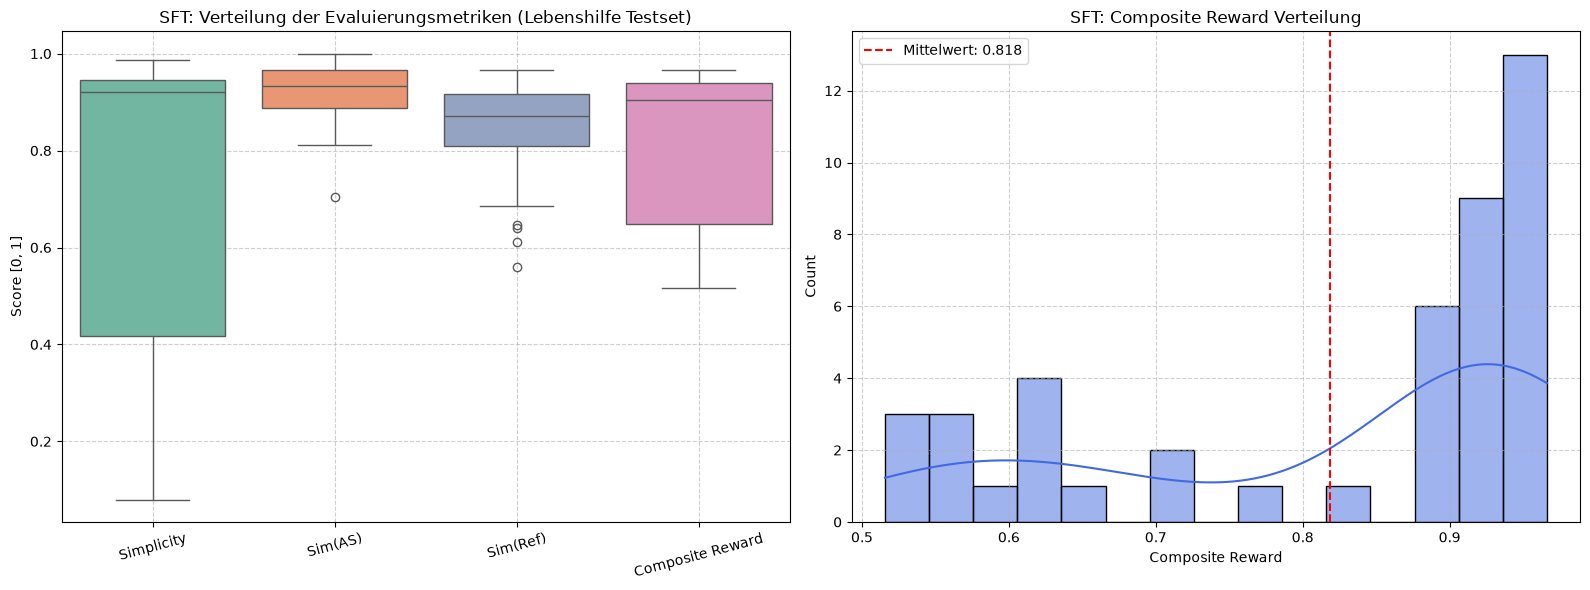

In [8]:
os.makedirs("results/plots", exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Boxplot der Metriken
sns.boxplot(data=sft_eval_df[metrics_cols], ax=axes[0], palette="Set2")
axes[0].set_title("SFT: Verteilung der Evaluierungsmetriken (Lebenshilfe Testset)", fontsize=12)
axes[0].set_ylabel("Score [0, 1]")
axes[0].set_xticklabels(["Simplicity", "Sim(AS)", "Sim(Ref)", "Composite Reward"], rotation=15)
axes[0].grid(True, linestyle="--", alpha=0.6)

# 2. KDE / Histogramm des Composite Rewards
sns.histplot(sft_eval_df["composite_reward"], kde=True, ax=axes[1], color="royalblue", bins=15)
axes[1].axvline(sft_eval_df["composite_reward"].mean(), color="red", linestyle="--", label=f"Mittelwert: {sft_eval_df['composite_reward'].mean():.3f}")
axes[1].set_title("SFT: Composite Reward Verteilung", fontsize=12)
axes[1].set_xlabel("Composite Reward")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plot_out_path = "results/plots/sft_lebenshilfe_metrics.png"
plt.savefig(plot_out_path, dpi=300)
print(f"Plot gespeichert unter: {plot_out_path}")
plt.show()

## 7. Interaktiver Übersetzungstest

In [9]:
def translate_custom_text(text):
    inputs = tokenizer(text, return_tensors="pt", max_length=MAX_SOURCE_LEN, truncation=True).to(DEVICE)
    forced_bos_id = tokenizer.lang_code_to_id.get("de_DE", None) if hasattr(tokenizer, "lang_code_to_id") else None
    
    with torch.no_grad():
        generated_ids = sft_model.generate(
            input_ids=inputs["input_ids"],
            attention_mask=inputs.get("attention_mask"),
            max_length=MAX_TARGET_LEN,
            num_beams=4,
            repetition_penalty=2.5,
            no_repeat_ngram_size=3,
            early_stopping=True,
            forced_bos_token_id=forced_bos_id
        )
    translation = tokenizer.decode(generated_ids[0], skip_special_tokens=True).strip()
    
    tot_reward, r_style, r_sem_norm = reward_evaluator.compute_reward([text], [translation])
    
    print(f"[Eingabe (AS)]:\n{text}\n")
    print(f"[SFT-Übersetzung (LS)]:\n{translation}\n")
    print(f"[Scores]: Simplicity={r_style[0]:.3f} | SBERT(AS)={r_sem_norm[0]:.3f} | Composite Reward={tot_reward[0]:.3f}")
    return translation

test_input = "Das Arbeitslosengeld dient der Sicherung des Lebensunterhalts während der Arbeitslosigkeit und wird nach bestimmten Kriterien bewilligt."
test_input_hund = "Hunde (Canis lupus familiaris) begleiten den Menschen seit Jahrtausenden und gelten als das älteste domestizierte Haustier. Sie stammen vom Wolf ab und haben sich im Laufe der Zeit perfekt an das Leben mit uns angepasst. Heute sind sie nicht nur beliebte Haustiere, sondern oft vollwertige Familienmitglieder, ausdauernde Arbeitstiere und therapeutische Helfer."

translate_custom_text(test_input)
translate_custom_text(test_input_hund)

test_text = "Hunde (Canis lupus familiaris) begleiten den Menschen seit Jahrtausenden und gelten als das älteste domestizierte Haustier. Sie stammen vom Wolf ab und haben sich im Laufe der Zeit perfekt an das Leben mit uns angepasst. Heute sind sie nicht nur beliebte Haustiere, sondern oft vollwertige Familienmitglieder, ausdauernde Arbeitstiere und therapeutische Helfer."

inputs = tokenizer(test_text, return_tensors="pt").to(DEVICE)
forced_bos_id = tokenizer.lang_code_to_id.get("de_DE", None)

for penalty in [1.0, 1.2, 2.5]:
    out = sft_model.generate(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_length=200,
        num_beams=4,
        repetition_penalty=penalty,
        forced_bos_token_id=forced_bos_id,
        early_stopping=True,
    )
    gen = tokenizer.decode(out[0], skip_special_tokens=True)
    print("=" * 60)
    print(f"Repetition Penalty: {penalty}")
    print("=" * 60)
    print(gen)
    print("\n")

[Eingabe (AS)]:
Das Arbeitslosengeld dient der Sicherung des Lebensunterhalts während der Arbeitslosigkeit und wird nach bestimmten Kriterien bewilligt.

[SFT-Übersetzung (LS)]:
Wie bekomme ich Arbeitslosengeld?

[Scores]: Simplicity=0.680 | SBERT(AS)=0.826 | Composite Reward=0.753
[Eingabe (AS)]:
Hunde (Canis lupus familiaris) begleiten den Menschen seit Jahrtausenden und gelten als das älteste domestizierte Haustier. Sie stammen vom Wolf ab und haben sich im Laufe der Zeit perfekt an das Leben mit uns angepasst. Heute sind sie nicht nur beliebte Haustiere, sondern oft vollwertige Familienmitglieder, ausdauernde Arbeitstiere und therapeutische Helfer.

[SFT-Übersetzung (LS)]:
Hunde begleiten uns seit vielen Jahren. Sie sind das älteste Haustier von Menschen. Hunde gehören zu der Familie von Hunden. Die Familienmitglieder sind oft sehr ausdauernde Arbeitstiere und therapeutische Helfer. Hier erfahren Sie mehr über die richtige Pflege von einem Hund.

[Scores]: Simplicity=0.950 | SBERT(